In [1]:
# 1 — Rebuild the waiting-time base (same rules and 10 terminals as notebooks 07 and 10)
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

candidates = [Path.cwd(), *Path.cwd().parents]
BASE = next((p for p in candidates if (p / "data" / "processed").exists()), None)
if BASE is None:
    raise FileNotFoundError(f"data/processed not found from {Path.cwd()} - run from inside the project folder.")
PROC = BASE / "data" / "processed"

calls = pd.read_csv(PROC / "calls_2024_2025.csv", parse_dates=["ts_arrival", "ts_berth", "ts_unberth"])
calls["terminal"] = calls["port"].str.strip() + " | " + calls["terminal_raw"].fillna("").str.strip()
calls["wait_h"] = (calls["ts_berth"] - calls["ts_arrival"]).dt.total_seconds() / 3600
calls["imo"] = pd.to_numeric(calls["imo"], errors="coerce")
calls["file_year_start"] = pd.to_datetime(calls["year"].astype(str) + "-01-01")

lc = calls[calls["navigation"] == "Longo Curso"]
w = lc[lc["ts_arrival"].between("2024-01-01", "2025-12-14 23:59")].copy()
w["arr_year"] = w["ts_arrival"].dt.year
w["month_p"] = w["ts_arrival"].dt.to_period("M")

prof = w.groupby(["terminal", "arr_year"]).agg(
    n=("call_id", "size"), teu=("teu", "mean"), p50=("wait_h", "median"),
    p90=("wait_h", lambda s: s.quantile(0.9)), below_1h=("wait_h", lambda s: (s < 1).mean())).unstack("arr_year")
ok = lambda y: (prof[("n", y)] >= 100) & (prof[("teu", y)] >= 300) & (prof[("below_1h", y)] <= 0.5) \
               & (prof[("p90", y)] / prof[("p50", y)] >= 2)
TERMINALS = prof.index[ok(2024) & ok(2025)].tolist()

uni = w[w["terminal"].isin(TERMINALS)].copy()
monthly = uni.groupby(["terminal", "month_p"]).size().unstack(fill_value=0).astype(float)
dec25 = pd.Period("2025-12", "M")
monthly[dec25] = monthly[dec25] * 31 / 14
low = monthly.lt(0.5 * monthly.drop(columns=[dec25]).median(axis=1), axis=0)
GAP_MONTHS = {(t, m) for t in low.index for m in low.columns if low.loc[t, m]}

mdf = uni[[(t, m) not in GAP_MONTHS for t, m in zip(uni["terminal"], uni["month_p"])]]
mdf = mdf[mdf["wait_h"].between(0, 14 * 24)
          & (mdf["ts_arrival"] >= mdf["file_year_start"] - pd.Timedelta(days=31))].copy()
mdf["month"] = mdf["ts_arrival"].dt.month

src = calls.dropna(subset=["ts_arrival", "ts_berth", "ts_unberth"])
src = src[(src["ts_arrival"] >= "2023-12-01") & src["wait_h"].between(0, 30 * 24)]
parts = []
for t, b in mdf.groupby("terminal"):
    s = src[src["terminal"] == t]
    t0 = b["ts_arrival"].values[:, None]
    arr, ber, unb = (s[c].values[None, :] for c in ["ts_arrival", "ts_berth", "ts_unberth"])
    parts.append(pd.DataFrame({"call_id": b["call_id"].values,
                               "q_waiting": ((arr < t0) & (ber > t0)).sum(axis=1),
                               "q_at_berth": ((ber <= t0) & (unb > t0)).sum(axis=1)}))
mdf = mdf.merge(pd.concat(parts), on="call_id", validate="1:1")

print(f"Terminals: {len(TERMINALS)} | calls by arrival year: {mdf['arr_year'].value_counts().sort_index().to_dict()}")
print("Median wait (h):", mdf.groupby("arr_year")["wait_h"].median().round(1).to_dict())
print("Excluded low-activity months:", sorted((t.split(' | ')[0][:18], str(m)) for t, m in GAP_MONTHS))

Terminals: 10 | calls by arrival year: {2024: 4227, 2025: 4389}
Median wait (h): {2024: 17.6, 2025: 15.2}
Excluded low-activity months: [('Salvador', '2025-08'), ('Salvador', '2025-12'), ('Terminal Portuário', '2024-05'), ('Terminal Portuário', '2024-06')]


In [2]:
# 2 — Rebuild each vessel's string of Brazilian calls and the position of every call in it
seq = (calls.dropna(subset=["imo", "ts_arrival", "ts_unberth"])
       .query("ts_arrival >= '2023-12-01'").sort_values(["imo", "ts_arrival"]).copy())
seq["prev_unberth"] = seq.groupby("imo")["ts_unberth"].shift()
seq["gap_days"] = (seq["ts_arrival"] - seq["prev_unberth"]).dt.total_seconds() / 86400

bins = [-np.inf, 0, 1, 2, 3, 4, 5, 7, 10, 14, 21, 30, np.inf]
print("Gap between leaving one Brazilian port and arriving at the next, same vessel (% of gaps):")
print((100 * pd.cut(seq["gap_days"].dropna(), bins).value_counts(normalize=True).sort_index()).round(1).to_string(), "\n")

def positions(max_gap_days):
    new = seq["gap_days"].isna() | (seq["gap_days"] > max_gap_days)
    sid = new.cumsum()
    return sid, seq.groupby(sid).cumcount() + 1, seq.groupby(sid)["call_id"].transform("size")

for G in (3, 5, 7):
    sid, pos, ln = positions(G)
    lens = ln.groupby(sid).first()
    print(f"Threshold {G} days: {sid.nunique():,} strings | calls per string: median {lens.median():.0f}, "
          f"P90 {lens.quantile(0.9):.0f} | strings with 1 call: {100 * (lens == 1).mean():.0f}%")

seq["string_id"], seq["pos"], seq["str_len"] = positions(5)
seq["port_short"] = seq["port"].str.split(" - ").str[0].str[:14]
first4 = (seq[seq["pos"] <= 4].groupby("string_id")["port_short"].agg(" > ".join))
print("\nMost common opening sequences (first 4 Brazilian calls, threshold 5 days):")
print(first4.value_counts().head(12).to_string(), "\n")

mdf = mdf.merge(seq[["call_id", "string_id", "pos", "str_len", "gap_days"]], on="call_id", how="left", validate="1:1")
mdf["pos_band"] = pd.cut(mdf["pos"], [0, 1, 2, 3, np.inf], labels=["1st", "2nd", "3rd", "4th+"])
print(f"Calls at the 10 terminals with a position: {mdf['pos'].notna().sum():,} of {len(mdf):,}")
pb = pd.crosstab(mdf["terminal"], mdf["pos_band"], normalize="index") * 100
pb.index = [t.split(" | ")[0][:18] + " | " + t.split(" | ")[-1][:16] for t in pb.index]
print("\nPosition of each terminal's calls within the vessel's Brazilian string (% of its calls):")
print(pb.round(0).sort_values("1st", ascending=False).to_string())

Gap between leaving one Brazilian port and arriving at the next, same vessel (% of gaps):
gap_days
(-inf, 0.0]      2.3
(0.0, 1.0]      36.0
(1.0, 2.0]      17.7
(2.0, 3.0]       8.1
(3.0, 4.0]       5.6
(4.0, 5.0]       4.0
(5.0, 7.0]       4.9
(7.0, 10.0]      5.1
(10.0, 14.0]     2.2
(14.0, 21.0]     0.8
(21.0, 30.0]     1.5
(30.0, inf]     11.9 

Threshold 3 days: 6,925 strings | calls per string: median 2, P90 5 | strings with 1 call: 38%
Threshold 5 days: 5,326 strings | calls per string: median 2, P90 6 | strings with 1 call: 28%
Threshold 7 days: 4,515 strings | calls per string: median 3, P90 6 | strings with 1 call: 24%

Most common opening sequences (first 4 Brazilian calls, threshold 5 days):
port_short
Santos                             508
Porto Chibatão                     150
Santos > Paranaguá                 149
Paranaguá > Santos                 118
Santos > Porto Itapoá T            110
Rio de Janeiro                     106
Itaguaí                            100
DP

In [3]:
# 3 — Question E: do ships arriving from a long voyage wait more than those coming from the previous Brazilian port?
m = mdf[mdf["ts_arrival"] >= "2024-03-01"].copy()          # at least 3 months of history for every vessel
m["log_w"] = np.log1p(m["wait_h"])
m["ym"] = m["ts_arrival"].dt.to_period("M")
m["week"] = m["ts_arrival"].dt.to_period("W")
g = m.groupby(["terminal", "ym"])["log_w"]
m["excess"] = (m["log_w"] - g.transform("median")).where(g.transform("size") >= 5)
m["q_band"] = m["q_waiting"].clip(upper=3)
g2 = m.groupby(["terminal", "ym", "q_band"])["log_w"]
m["excess_q"] = (m["log_w"] - g2.transform("median")).where(g2.transform("size") >= 5)

m["arrival_type"] = np.select(
    [m["gap_days"].isna() | (m["gap_days"] > 14), m["gap_days"] > 5],
    ["long voyage (>14 d)", "back from nearby abroad (5-14 d)"], default="coastal hop (<=5 d)")
m["gap_band"] = pd.cut(m["gap_days"].fillna(999), [-np.inf, 1, 2, 3, 5, 14, np.inf],
                       labels=["<=1 d", "1-2 d", "2-3 d", "3-5 d", "5-14 d", ">14 d"])

rng = np.random.default_rng(42)
def boot_ci(x, weeks, n_boot=1000):
    d = pd.DataFrame({"x": x, "w": weeks}).dropna()
    groups = [gg["x"].to_numpy() for _, gg in d.groupby("w")]
    k = len(groups)
    meds = [np.median(np.concatenate([groups[j] for j in rng.integers(0, k, k)])) for _ in range(n_boot)]
    return np.percentile(meds, [2.5, 97.5])
pct = lambda v: 100 * (np.exp(v) - 1)

def compare(df, col):
    rows = []
    for key, d in df.groupby(col, observed=True):
        lo, hi = boot_ci(d["excess"], d["week"])
        rows.append({col: key, "calls": len(d), "median_wait_h": d["wait_h"].median(),
                     "mean_queue_on_arrival": d["q_waiting"].mean(),
                     "vs_same_terminal_month_%": pct(d["excess"].median()), "CI_low_%": pct(lo), "CI_high_%": pct(hi),
                     "also_same_queue_%": pct(d["excess_q"].median())})
    return pd.DataFrame(rows).set_index(col).round(1)

print("By type of arrival:")
print(compare(m, "arrival_type").to_string(), "\n")
print("By time since the vessel last left a Brazilian port:")
print(compare(m, "gap_band").to_string(), "\n")

coastal = m[m["arrival_type"] == "coastal hop (<=5 d)"].copy()
coastal["pos_c"] = pd.cut(coastal["pos"], [1, 2, 3, np.inf], labels=["2nd call", "3rd call", "4th+ call"])
print("Coastal hops only, by position along the coast:")
print(compare(coastal, "pos_c").to_string(), "\n")

tt = (m[m["arrival_type"] != "back from nearby abroad (5-14 d)"]
      .groupby(["terminal", "arrival_type"]).agg(calls=("call_id", "size"), ex=("excess", "median"))
      .unstack("arrival_type"))
out = pd.DataFrame({"long_voyage_calls": tt[("calls", "long voyage (>14 d)")],
                    "coastal_calls": tt[("calls", "coastal hop (<=5 d)")],
                    "long_voyage_vs_peers_%": pct(tt[("ex", "long voyage (>14 d)")]),
                    "coastal_vs_peers_%": pct(tt[("ex", "coastal hop (<=5 d)")])})
out["difference_pp"] = out["long_voyage_vs_peers_%"] - out["coastal_vs_peers_%"]
out.index = [t.split(" | ")[0][:18] + " | " + t.split(" | ")[-1][:16] for t in out.index]
print("By terminal: long-voyage arrivals vs coastal hops:")
print(out.round(1).sort_values("difference_pp", ascending=False).to_string())

By type of arrival:


                                  calls  median_wait_h  mean_queue_on_arrival  vs_same_terminal_month_%  CI_low_%  CI_high_%  also_same_queue_%
arrival_type                                                                                                                                   
back from nearby abroad (5-14 d)   1161           12.2                    1.8                      -6.9     -15.1       -1.3               -3.5
coastal hop (<=5 d)                5247           19.0                    2.0                       4.2       0.7        7.8                1.4
long voyage (>14 d)                1495           13.2                    2.1                     -10.5     -19.2       -3.1               -7.6 

By time since the vessel last left a Brazilian port:
          calls  median_wait_h  mean_queue_on_arrival  vs_same_terminal_month_%  CI_low_%  CI_high_%  also_same_queue_%
gap_band                                                                                                 

In [4]:
# 4 — Are the short hops terminal shifts inside the same port?
def port_group(p):
    p = str(p)
    if "Santos" in p:
        return "Santos"
    if p.startswith("Paranaguá"):
        return "Paranaguá"
    if p.startswith("Rio de Janeiro"):
        return "Rio de Janeiro"
    return p

seq["pg"] = seq["port"].map(port_group)
seq["prev_pg"] = seq.groupby("imo")["pg"].shift()
seq["prev_terminal"] = seq.groupby("imo")["terminal"].shift()
m = m.merge(seq[["call_id", "pg", "prev_pg", "prev_terminal"]], on="call_id", how="left", validate="1:1")

m["hop_type"] = np.select(
    [m["arrival_type"] != "coastal hop (<=5 d)", m["pg"] == m["prev_pg"]],
    ["not a coastal hop", "terminal shift within the same port"], default="from another Brazilian port")
print("Coastal hops split by where the vessel came from:")
print(compare(m, "hop_type").to_string(), "\n")

short = m[m["gap_band"] == "<=1 d"]
print(f"Hops of 1 day or less: {len(short):,} | terminal shifts within the same port: "
      f"{100 * (short['hop_type'] == 'terminal shift within the same port').mean():.0f}%")
shift_pairs = (m[m["hop_type"] == "terminal shift within the same port"]
               .assign(pair=lambda d: d["prev_terminal"].str.split(" | ").str[-1].str[:22] + " -> "
                       + d["terminal"].str.split(" | ").str[-1].str[:22]))
print("Most common terminal shifts:")
print(shift_pairs["pair"].value_counts().head(8).to_string(), "\n")

other = m[m["hop_type"] != "terminal shift within the same port"]
print("Without terminal shifts — by time since the vessel last left a Brazilian port:")
print(compare(other, "gap_band").to_string(), "\n")

coastal2 = m[m["hop_type"] == "from another Brazilian port"].copy()
coastal2["pos_c"] = pd.cut(coastal2["pos"], [1, 2, 3, np.inf], labels=["2nd call", "3rd call", "4th+ call"])
print("Coastal hops from another port only, by position along the coast:")
print(compare(coastal2, "pos_c").to_string())

Coastal hops split by where the vessel came from:
                                     calls  median_wait_h  mean_queue_on_arrival  vs_same_terminal_month_%  CI_low_%  CI_high_%  also_same_queue_%
hop_type                                                                                                                                          
from another Brazilian port           5098           18.8                    2.0                       4.0       0.7        7.3                1.6
not a coastal hop                     2656           12.7                    2.0                      -9.2     -15.0       -4.2               -6.3
terminal shift within the same port    149           23.4                    2.6                      14.4     -10.5       39.9                0.0 

Hops of 1 day or less: 3,715 | terminal shifts within the same port: 3%
Most common terminal shifts:
pair
S.A. -> S.A.                39
Pecém -> Pecém              28
Privativo -> Privativo      26
Privativo -> S

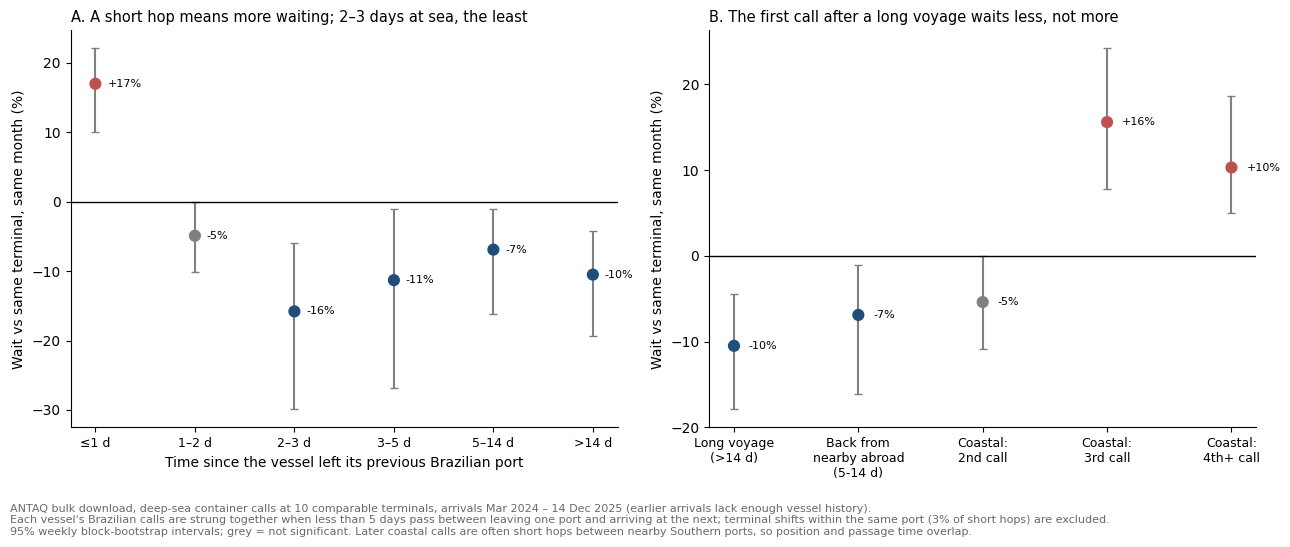

In [5]:
# 5 — Figure (fig17): short hops wait more, long passages wait less
FIG_DIR = BASE / "outputs" / "figures"
rng = np.random.default_rng(42)
gb = compare(other, "gap_band")
ta = compare(other, "arrival_type")
tb = compare(coastal2, "pos_c")
pb2 = pd.concat([ta.loc[["long voyage (>14 d)", "back from nearby abroad (5-14 d)"]], tb])
pb2.index = ["Long voyage\n(>14 d)", "Back from\nnearby abroad\n(5-14 d)", "Coastal:\n2nd call", "Coastal:\n3rd call",
             "Coastal:\n4th+ call"]

def dots(ax, t, labels):
    xx = np.arange(len(t))
    est = t["vs_same_terminal_month_%"]
    col = np.where(t["CI_low_%"] > 0, "#c0504d", np.where(t["CI_high_%"] < 0, "#1f4e79", "grey"))
    ax.errorbar(xx, est, yerr=[est - t["CI_low_%"], t["CI_high_%"] - est], fmt="none", ecolor="grey", capsize=3)
    ax.scatter(xx, est, color=col, s=60, zorder=3)
    for x_, v_ in zip(xx, est):
        ax.text(x_ + 0.12, v_, f"{v_:+.0f}%", va="center", fontsize=8)
    ax.axhline(0, color="black", lw=1)
    ax.set_xticks(xx, labels, fontsize=9)
    ax.set_ylabel("Wait vs same terminal, same month (%)")
    ax.spines[["top", "right"]].set_visible(False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
dots(ax1, gb, ["≤1 d", "1–2 d", "2–3 d", "3–5 d", "5–14 d", ">14 d"])
ax1.set_xlabel("Time since the vessel left its previous Brazilian port")
ax1.set_title("A. A short hop means more waiting; 2–3 days at sea, the least", loc="left", fontsize=10.5)
dots(ax2, pb2, list(pb2.index))
ax2.set_title("B. The first call after a long voyage waits less, not more", loc="left", fontsize=10.5)

fig.text(0.01, -0.08,
         "ANTAQ bulk download, deep-sea container calls at 10 comparable terminals, arrivals Mar 2024 – 14 Dec 2025 "
         "(earlier arrivals lack enough vessel history).\nEach vessel's Brazilian calls are strung together when less than "
         "5 days pass between leaving one port and arriving at the next; terminal shifts within the same port (3% of short "
         "hops) are excluded.\n95% weekly block-bootstrap intervals; grey = not significant. Later coastal calls are often "
         "short hops between nearby Southern ports, so position and passage time overlap.",
         fontsize=8, color="dimgrey")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig17_rotation_position.png", dpi=150, bbox_inches="tight")
plt.show()

## What this notebook answers

**Does the first Brazilian port of a voyage wait longer than the next ones?** No. The first call after a long voyage waits less; the calls that wait most are those reached after a very short passage from a nearby Brazilian port.

ANTAQ does not record where a ship comes from, so each vessel's Brazilian calls were strung together from their dates: a new string starts when more than 5 days pass between leaving one Brazilian port and arriving at the next. There is no natural break between coastal hops and foreign legs (22% of gaps fall between 3 and 14 days), and many "first" calls at Rio Grande are ships coming back from the River Plate. Arrivals were therefore classified by **time at sea since the previous Brazilian port**, which is the more direct measure.

Same base as notebooks 07, 10 and 13 (10 comparable terminals), arrivals from March 2024 so that every vessel has at least three months of history. Comparisons are against other ships at the same terminal in the same month.

- **After a long voyage (over 14 days), ships wait about 10% less** (95% CI −19% to −4%), and 8% less with the same queue on arrival.
- **After a hop of a day or less from a nearby Brazilian port, ships wait about 17% more** (+11% to +22%), and still about 9% more with the same queue.
- **After 2–3 days at sea, ships wait about 16% less** (−30% to −6%).
- **Terminal shifts within the same port are not the explanation:** they are only 3% of the short hops.
- **Along the coast, the 3rd and 4th calls wait 10–16% more than the 2nd,** but later calls are often short hops between the Southern ports, so position and passage time cannot be cleanly separated.

**Likely reading (not proven):** a ship with two or three days at sea can slow down and arrive when the berth is ready; a ship sailing a few hours to the next port cannot, so it waits at anchor instead. Where Brazilian ports sit close together, as in the South, the anchorage absorbs schedule gaps that a longer passage would absorb at sea. This matches notebook 10, where "late" ships waited less than average.

## Limitations

1. **The vessel's route is inferred from Brazilian calls only;** foreign calls are invisible, so "long voyage" and "back from nearby abroad" are defined by time, not by where the ship came from.
2. **Passage time includes any time spent waiting outside ANTAQ's records,** such as slow steaming or drifting before logging arrival.
3. **Position along the coast and passage time overlap** and cannot be separated with this data.
4. **Association, not cause.** Speed adjustment is the most plausible explanation, but vessel speed is not in the data (no AIS).